# Why `exp1_inputs:input3g` training collapsed

## Executive finding

The hypothesis is **confirmed**: numerically extreme normalized sea-ice-thickness (`icethick`) values reach approximately $4.8\times10^{13}$ and cause the trained model to collapse to essentially the zero-anomaly predictor. The extreme values are not large physical thicknesses. They are created by dividing by near-zero per-grid-cell/month training ranges, then made worse by a detrending fit that uses all ensemble members (including validation and test members) and broadcasts the contaminated trend back onto every member.

This notebook uses the actual Slurm log, normalized data, precomputed pair, and epoch-10 checkpoint. It is read-only: running it does not alter any artifact.

Text(0.5, 1.0, 'pointwise min')

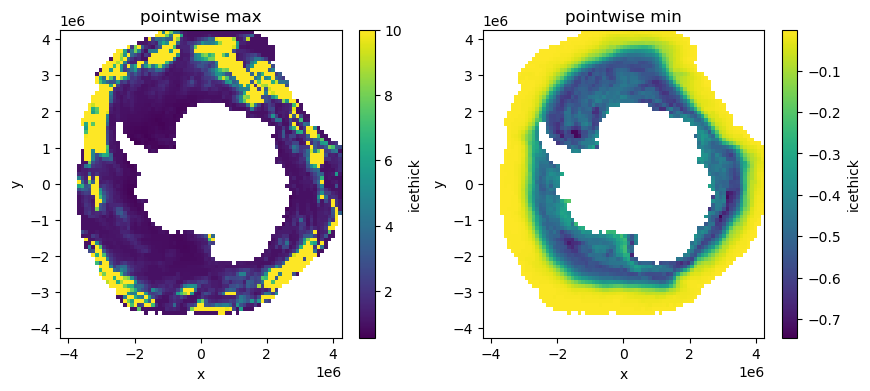

In [19]:
# after clipping to [-10, 10]
import xarray as xr
import matplotlib.pyplot as plt
ds = xr.open_dataset("/scratch/users/yucli/cesm_data_processed/normalized_inputs/all_inputs_no_sic/icethick_norm.nc")
da = ds["icethick"]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
da.max(("time", "member_id")).plot(ax=axs[0])
da.min(("time", "member_id")).plot(ax=axs[1])
axs[0].set_title("pointwise max")
axs[1].set_title("pointwise min")

In [1]:
from pathlib import Path
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr

# Find the repository whether the notebook is launched from the repo root or its own directory.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir())
sys.path.insert(0, str(repo_root))

from src import config_cesm
from src.experiment_configs import load_config
from src.models.models import UNetRes3
from src.utils import util_cesm

config = load_config('exp1_inputs:input3g')
normalized_dir = Path(config_cesm.PROCESSED_DATA_DIRECTORY) / 'normalized_inputs' / config.data_name
pairs_dir = Path(config_cesm.PROCESSED_DATA_DIRECTORY) / 'data_pairs' / config.data_name
model_dir = Path(config_cesm.MODEL_DIRECTORY) / config.experiment_name
log_path = repo_root / 'logs' / 'sicpred_new_inputs.42348878_2.out'
norm_path = normalized_dir / 'icethick_norm.nc'
checkpoint_path = model_dir / 'UNetRes3_exp1_input3g_member_0_epoch_10.pth'

required = [log_path, norm_path, checkpoint_path]
missing = [str(path) for path in required if not path.exists()]
assert not missing, f'Missing artifacts: {missing}'
print(f'Configuration: {config.experiment_name} ({config.data_name})')
print(f'Log:          {log_path}')
print(f'Normalized:   {norm_path}')
print(f'Checkpoint:   {checkpoint_path}')

Configuration: exp1_input3g (seaice_plus_icethick)
Log:          /home/users/yucli/sicpred/logs/sicpred_new_inputs.42348878_2.out
Normalized:   /scratch/users/yucli/cesm_data_processed/normalized_inputs/seaice_plus_icethick/icethick_norm.nc
Checkpoint:   /oak/stanford/groups/earlew/yuchen/sicpred/sicpred_models/exp1_input3g/UNetRes3_exp1_input3g_member_0_epoch_10.pth


## 1. The run converged to a flat, high-loss solution

The epoch number resets when training advances to the next independently initialized ensemble member. Both attempted members show the same rapid plateau.

,member,epoch,train_loss,val_loss
0,0,1,0.0056,0.0053
1,0,2,0.0054,0.0053
2,0,3,0.0054,0.0053
3,0,4,0.0054,0.0053
4,0,5,0.0054,0.0053
5,0,6,0.0054,0.0053
6,0,7,0.0054,0.0053
7,0,8,0.0054,0.0053
8,0,9,0.0054,0.0053
9,0,10,0.0054,0.0053


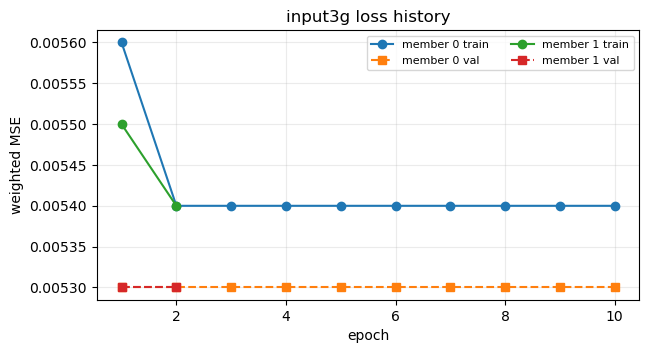

In [2]:
pattern = re.compile(r'Epoch (\d+) - Train Loss: ([0-9.eE+-]+), Val Loss: ([0-9.eE+-]+)')
records = []
member = 0
previous_epoch = 0
for epoch_text, train_text, val_text in pattern.findall(log_path.read_text()):
    epoch = int(epoch_text)
    if epoch <= previous_epoch:
        member += 1
    records.append({'member': member, 'epoch': epoch,
                    'train_loss': float(train_text), 'val_loss': float(val_text)})
    previous_epoch = epoch
losses = pd.DataFrame(records)
display(losses)

fig, ax = plt.subplots(figsize=(7, 3.5))
for member_id, frame in losses.groupby('member'):
    ax.plot(frame.epoch, frame.train_loss, marker='o', label=f'member {member_id} train')
    ax.plot(frame.epoch, frame.val_loss, marker='s', linestyle='--', label=f'member {member_id} val')
ax.set(xlabel='epoch', ylabel='weighted MSE', title='input3g loss history')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.25);

### Negative controls from the same Slurm array

The configurations without `icethick` provide a direct negative control: their validation losses improve substantially, whereas every configuration containing `icethick` stays at the zero-prediction plateau. Values below are parsed from the available `.out` logs, including completed epochs from partially finished ensemble runs.

In [3]:
array_variants = [
    (0, 'input3e', False), (1, 'input3f', False), (2, 'input3g', True),
    (3, 'input4a', False), (4, 'input4b', False), (5, 'input5', True),
    (6, 'input5_noSIC', True),
]
control_rows = []
for task_id, variant, contains_icethick in array_variants:
    path = repo_root / 'logs' / f'sicpred_new_inputs.42348878_{task_id}.out'
    matches = pattern.findall(path.read_text()) if path.exists() else []
    validation_losses = [float(match[2]) for match in matches]
    control_rows.append({
        'configuration': variant,
        'contains icethick': contains_icethick,
        'logged epochs': len(validation_losses),
        'first val loss': validation_losses[0] if validation_losses else np.nan,
        'best val loss': min(validation_losses) if validation_losses else np.nan,
        'latest val loss': validation_losses[-1] if validation_losses else np.nan,
        'first-to-best improvement': (validation_losses[0] - min(validation_losses)) if validation_losses else np.nan,
    })
negative_controls = pd.DataFrame(control_rows).set_index('configuration')
display(negative_controls)


,contains icethick,logged epochs,first val loss,best val loss,latest val loss,first-to-best improvement
configuration,,,,,,
input3e,False,38,0.0045,0.0035,0.0036,0.0010
input3f,False,26,0.0042,0.0035,0.0036,0.0007
input3g,True,12,0.0053,0.0053,0.0053,0.0000
input4a,False,35,0.0041,0.0035,0.0036,0.0006
input4b,False,34,0.0042,0.0035,0.0037,0.0007
input5,True,10,0.0053,0.0053,0.0053,0.0000
input5_noSIC,True,9,0.0053,0.0053,0.0053,0.0000


## 2. The normalized thickness artifact contains enormous finite values

Loading this file requires about 0.7 GB of RAM. We report finite-value counts separately from missing values. Missing values are later filled with zero when input pairs are built; the extreme finite values are not removed.

In [4]:
with xr.open_dataset(norm_path) as ds:
    icethick = ds['icethick'].load()

values = icethick.values
finite = np.isfinite(values)
absolute = np.abs(values[finite])
summary = pd.Series({
    'finite values': int(finite.sum()),
    'NaN values': int(np.isnan(values).sum()),
    'infinite values': int(np.isinf(values).sum()),
    'median |value|': float(np.median(absolute)),
    '99.9th percentile |value|': float(np.quantile(absolute, 0.999)),
    'maximum |value|': float(absolute.max()),
    'count |value| > 1e6': int((absolute > 1e6).sum()),
    'count |value| > 1e10': int((absolute > 1e10).sum()),
})
display(summary.to_frame('result'))

split_rows = []
for split in ('train', 'val', 'test'):
    split_values = icethick.sel(member_id=config.data_split[split]).values
    split_rows.append({
        'split': split,
        'members': len(config.data_split[split]),
        'maximum |value|': float(np.nanmax(np.abs(split_values))),
        'count |value| > 1e10': int(np.sum(np.abs(split_values) > 1e10)),
    })
display(pd.DataFrame(split_rows).set_index('split'))

,result
finite values,7.619388e+07
NaN values,1.000493e+08
infinite values,0.000000e+00
median |value|,2.713713e-02
99.9th percentile |value|,8.262070e+00
maximum |value|,4.834153e+13
count |value| > 1e6,1.173100e+04
count |value| > 1e10,1.752000e+03


,members,maximum |value|,count |value| > 1e10
split,,,
train,8,5.196186e+10,1000
val,2,2.408914e+11,250
test,4,4.834153e+13,502


## 3. Root cause: near-zero min–max ranges, followed by cross-split detrending

`normalize_data` first applies a separate min–max transform at every grid cell and calendar month. It checks for exact zero only in the standard-deviation branch, not in the min–max branch. At marginal cells, a nonzero but numerically negligible training range can therefore be used as the denominator.

At the worst cell below, the April training range is only $1.27\times10^{-16}$. A held-out test-member thickness of 0.0061 m is consequently transformed to $4.84\times10^{13}$. The subsequent quadratic detrending fit averages over **all 14 members**, rather than fitting only the eight training members. The contaminated fitted trend is then subtracted from every member, turning a raw training value of exactly zero into $-5.20\times10^{10}$. This is both numerical instability and train/validation/test leakage.

In [5]:
min_path = normalized_dir / 'icethick_min.nc'
max_path = normalized_dir / 'icethick_max.nc'
raw_path = Path(config_cesm.DATA_DIRECTORY) / 'cesm_data' / 'icethick' / 'icethick_combined.nc'

with xr.open_dataset(min_path) as min_ds, xr.open_dataset(max_path) as max_ds:
    monthly_min = min_ds['icethick'].load()
    monthly_max = max_ds['icethick'].load()
ranges = monthly_max - monthly_min
positive_ranges = ranges.values[ranges.values > 0]
range_summary = pd.Series({
    'exactly zero ranges': int(np.sum(ranges.values == 0)),
    'positive ranges < 1e-12': int(np.sum((ranges.values > 0) & (ranges.values < 1e-12))),
    'positive ranges < 1e-8': int(np.sum((ranges.values > 0) & (ranges.values < 1e-8))),
    'smallest positive range': float(positive_ranges.min()),
})
display(range_summary.to_frame('result'))

# Locate the global post-detrending extreme and the largest extreme in a training member.
global_index = np.unravel_index(np.nanargmax(np.abs(values)), values.shape)
train_values = icethick.sel(member_id=config.data_split['train']).values
train_local_index = np.unravel_index(np.nanargmax(np.abs(train_values)), train_values.shape)
train_index = (train_local_index[0], train_local_index[1], train_local_index[2], train_local_index[3])
points = [
    ('training contamination', config.data_split['train'][train_index[0]],
     pd.Timestamp(icethick.time.values[train_index[1]]), train_index[2], train_index[3]),
    ('global extreme', str(icethick.member_id.values[global_index[0]]),
     pd.Timestamp(icethick.time.values[global_index[1]]), global_index[2], global_index[3]),
]

rows = []
with xr.open_dataset(raw_path) as raw_ds:
    for label, member_id, time, y_index, x_index in points:
        month = time.month
        minimum = monthly_min.sel(month=month).isel(y=y_index, x=x_index).item()
        maximum = monthly_max.sel(month=month).isel(y=y_index, x=x_index).item()
        denominator = maximum - minimum
        raw = raw_ds['icethick'].sel(member_id=member_id, time=time).isel(y=y_index, x=x_index).item()
        before_detrend = (raw - minimum) / denominator
        after_detrend = icethick.sel(member_id=member_id, time=time).isel(y=y_index, x=x_index).item()
        rows.append({
            'case': label, 'member': member_id, 'time': time.date(), 'y index': y_index, 'x index': x_index,
            'raw thickness': raw, 'training range': denominator,
            'after min-max': before_detrend, 'after detrending': after_detrend,
            'subtracted fitted trend': before_detrend - after_detrend,
        })
root_cause = pd.DataFrame(rows).set_index('case')
display(root_cause.T)

,result
exactly zero ranges,2.786700e+04
positive ranges < 1e-12,2.100000e+01
positive ranges < 1e-8,1.630000e+02
smallest positive range,4.600255e-18


case,training contamination,global extreme
member,r10i1181p1f1,r3i1041p1f1
time,1851-04-01,1887-04-01
y index,50,50
x index,10,10
raw thickness,0.0,0.006129
training range,0.0,0.0
after min-max,0.0,48382412553940.070312
after detrending,-51961860096.0,48341530443776.0
subtracted fitted trend,51961860096.0,40882110164.070312


## 4. The extreme value survives into the model-ready pair

The training contamination above occurs in April 1851. For the May 1851 initialization it is the one-month-lag `icethick` channel. The precomputed input-pair value exactly matches the normalized artifact, so pair construction does not cause or repair it.

In [6]:
train_member = config.data_split['train'][0]
pair_path = pairs_dir / f'inputs_member_{train_member}.nc'
with xr.open_dataset(pair_path) as pair_ds:
    channels = pair_ds.channel.values.astype(str).tolist()
    pair_value = pair_ds['data'].sel(
        start_prediction_month='1851-05-01', channel='icethick_lag1'
    ).isel(y=50, x=10).item()
normalized_value = icethick.sel(
    member_id=train_member, time='1851-04-01'
).isel(y=50, x=10).item()
print('Channels:', channels)
print(f'Normalized time-series value: {normalized_value:.6g}')
print(f'Precomputed-pair value:       {pair_value:.6g}')
assert pair_value == normalized_value

Channels: ['icefrac_lag12', 'icefrac_lag11', 'icefrac_lag10', 'icefrac_lag9', 'icefrac_lag8', 'icefrac_lag7', 'icefrac_lag6', 'icefrac_lag5', 'icefrac_lag4', 'icefrac_lag3', 'icefrac_lag2', 'icefrac_lag1', 'icethick_lag6', 'icethick_lag5', 'icethick_lag4', 'icethick_lag3', 'icethick_lag2', 'icethick_lag1', 'cosine_of_init_month', 'sine_of_init_month', 'land_mask']
Normalized time-series value: -5.19619e+10
Precomputed-pair value:       -5.19619e+10


## 5. The saved model collapsed to zero-anomaly predictions

The first convolution turns the already extreme input into activations as large as billions. In the epoch-10 checkpoint, representative early- and mid-record samples from both training and validation members produce exactly zero everywhere after the model's near-zero-output clipping. This is the zero-anomaly/climatology solution.

In [7]:
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model = UNetRes3(
    in_channels=util_cesm.get_num_input_channels(config.input_config),
    out_channels=util_cesm.get_num_output_channels(config.max_lead_months, config.target_config),
    predict_anomalies=config.target_config['predict_anom'],
    **config.model_args,
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def inspect_prediction(member_id, start_month):
    path = pairs_dir / f'inputs_member_{member_id}.nc'
    with xr.open_dataset(path) as ds:
        sample = ds['data'].sel(start_prediction_month=start_month).values.astype('float32')
        channel_names = ds.channel.values.astype(str)
    icethick_channels = np.char.startswith(channel_names, 'icethick_')
    activations = {}
    hook = model.encoder1[0].register_forward_hook(
        lambda _module, _inputs, output: activations.update(first_conv=output.detach())
    )
    with torch.no_grad():
        prediction = model(torch.from_numpy(sample[None]))
    hook.remove()
    prediction = prediction.numpy()
    first_conv = activations['first_conv'].numpy()
    return {
        'member': member_id, 'initialization': start_month,
        'input maximum |value|': float(np.abs(sample).max()),
        'icethick maximum |value|': float(np.abs(sample[icethick_channels]).max()),
        'first-conv maximum |activation|': float(np.abs(first_conv).max()),
        'prediction maximum |value|': float(np.abs(prediction).max()),
        'nonzero prediction fraction': float(np.mean(prediction != 0)),
    }

prediction_checks = pd.DataFrame([
    inspect_prediction(config.data_split['train'][0], '1851-05-01'),
    inspect_prediction(config.data_split['train'][0], '1900-01-01'),
    inspect_prediction(config.data_split['val'][0], '1900-01-01'),
])
display(prediction_checks.set_index(['member', 'initialization']))
print({key: checkpoint[key] for key in ('epoch', 'best_val_loss', 'best_epoch')})

input maximum |value|  icethick maximum |value|  \
member       initialization                                                    
r10i1181p1f1 1851-05-01               5.196186e+10              5.196186e+10   
             1900-01-01               5.939791e+08              5.939791e+08   
r1i1281p1f1  1900-01-01               5.939791e+08              5.939791e+08   

                             first-conv maximum |activation|  \
member       initialization                                    
r10i1181p1f1 1851-05-01                         4.014032e+09   
             1900-01-01                         5.779006e+07   
r1i1281p1f1  1900-01-01                         5.779006e+07   

                             prediction maximum |value|  \
member       initialization                               
r10i1181p1f1 1851-05-01                             0.0   
             1900-01-01                             0.0   
r1i1281p1f1  1900-01-01                             0.0   

                             nonzero prediction fraction  
member       initialization                               
r10i1181p1f1 1851-05-01                              0.0  
             1900-01-01                              0.0  
r1i1281p1f1  1900-01-01                              0.0

{'epoch': 10, 'best_val_loss': 0.005306965780384358, 'best_epoch': 10}


In [8]:
# Compare the logged plateau with the exact weighted-MSE baseline obtained by predicting zero
# for every validation target. This reads about 0.6 GB per validation member, one at a time.
with open(normalized_dir / 'month_weights.pkl', 'rb') as stream:
    month_weights = pickle.load(stream)
area_weights = util_cesm.calculate_area_weights()
numerator = 0.0
denominator = 0.0
for member_id in config.data_split['val']:
    with xr.open_dataset(pairs_dir / f'targets_member_{member_id}.nc') as target_ds:
        targets = target_ds['data'].values
        starts = pd.DatetimeIndex(target_ds.start_prediction_month.values)
    target_month_indices = np.stack(
        [((starts.month - 1 + lead) % 12) for lead in range(config.max_lead_months)], axis=1
    )
    weights = month_weights[target_month_indices][..., None, None] * area_weights[None, None]
    numerator += np.sum(weights * targets**2)
    denominator += np.sum(weights)
zero_baseline = numerator / denominator
best_logged = checkpoint['best_val_loss']
print(f'Exact zero-prediction validation loss: {zero_baseline:.9f}')
print(f'Checkpoint best validation loss:       {best_logged:.9f}')
print(f'Relative difference:                   {(best_logged / zero_baseline - 1) * 100:.3f}%')

Exact zero-prediction validation loss: 0.005321736
Checkpoint best validation loss:       0.005306966
Relative difference:                   -0.278%


## 6. Scope check: other configurations containing `icethick`

The same preprocessing logic and split were used for `input5` and `input5_noSIC`. The known contaminated scalar is identical in all three normalized artifacts, and the available `input5` logs show the same flat loss signature. These configurations should also be treated as invalid until `icethick` preprocessing is corrected and their pairs are regenerated.

In [9]:
affected_data_names = {
    'input3g': 'seaice_plus_icethick',
    'input5': 'seaice_plus_all_variables',
    'input5_noSIC': 'all_inputs_no_sic',
}
scope_rows = []
for variant, data_name in affected_data_names.items():
    path = Path(config_cesm.PROCESSED_DATA_DIRECTORY) / 'normalized_inputs' / data_name / 'icethick_norm.nc'
    with xr.open_dataset(path) as ds:
        value = ds['icethick'].sel(member_id=train_member, time='1851-04-01').isel(y=50, x=10).item()
    scope_rows.append({'configuration': variant, 'known contaminated value': value, 'path': str(path)})
display(pd.DataFrame(scope_rows).set_index('configuration'))

,known contaminated value,path
configuration,,
input3g,-5.196186e+10,/scratch/users/yucli/cesm_data_processed/norma...
input5,-5.196186e+10,/scratch/users/yucli/cesm_data_processed/norma...
input5_noSIC,-5.196186e+10,/scratch/users/yucli/cesm_data_processed/norma...


## Conclusion and recommended correction

The evidence confirms the proposed causal explanation with high confidence:

1. `icethick` contains ordinary physical values, but per-cell/month min–max normalization divides some of them by ranges close to machine zero.
2. A held-out-member value becomes approximately $4.84\times10^{13}$.
3. Detrending is fit using every split, so the resulting enormous fitted trend contaminates the training members too.
4. The corruption is present in the exact pair read by training.
5. The saved model emits zero everywhere on representative samples, and its validation loss differs from the exact zero-prediction baseline by less than 0.3%.

Do not resume `input3g`, `input5`, or `input5_noSIC` from these artifacts. A correction should (a) fit every normalization and detrending parameter using training data only, (b) guard min–max denominators with a physically/numerically meaningful tolerance rather than only checking equality to zero, and (c) validate finite values and an expected magnitude bound before writing pairs. Detrending before scaling, masking cells without meaningful ice thickness, or using a robust global/regional scale are reasonable scientific choices to evaluate. After choosing the intended treatment, regenerate both normalized `icethick` and all model-ready pairs before retraining.

## 7. Read-only range and extrapolation triage (pre-detrending)

This section isolates the min--max issue from the historical detrending leak above. It recomputes the transform directly from raw `icethick` and the existing **training-member** monthly min/max files, without reading post-detrending normalized values. Thus values here are $z=(h-h_{min})/(h_{max}-h_{min})$ before quadratic trend removal. The calculation streams one member at a time (about 50 MB of raw thickness) and does not write data, pairs, checkpoints, or figures.

`present fraction` is the fraction of finite training thickness samples exceeding 1 cm for a grid-cell/calendar-month. It is a descriptive marginal-ice indicator, not a production mask: the current pipeline has no icethick-specific near-ice mask.


,value
finite cell-months,6.106800e+04
zero-range cell-months,2.786700e+04
smallest positive range (m),4.600255e-18
1st percentile positive range (m),1.500419e-07
median positive range (m),7.311217e-01


,positive cell-months,zero range,median positive range (m),range < 1e-12 m,range < 1e-08 m,range < 1e-06 m,range < 0.0001 m,range < 0.001 m,range < 0.01 m
month,,,,,,,,,
1,3041,2048,0.378637,3,13,61,209,363,563
2,2768,2321,0.119676,1,19,76,240,415,714
3,2431,2658,0.072446,7,55,137,384,598,894
4,2031,3058,0.402928,7,31,74,216,331,507
5,2187,2902,0.700274,0,9,40,143,265,419
6,2544,2545,0.781492,0,8,34,155,293,463
7,2774,2315,0.888098,0,4,20,147,273,470
8,2943,2146,1.001750,0,3,16,120,242,457
9,3065,2024,1.082422,0,3,20,133,251,446


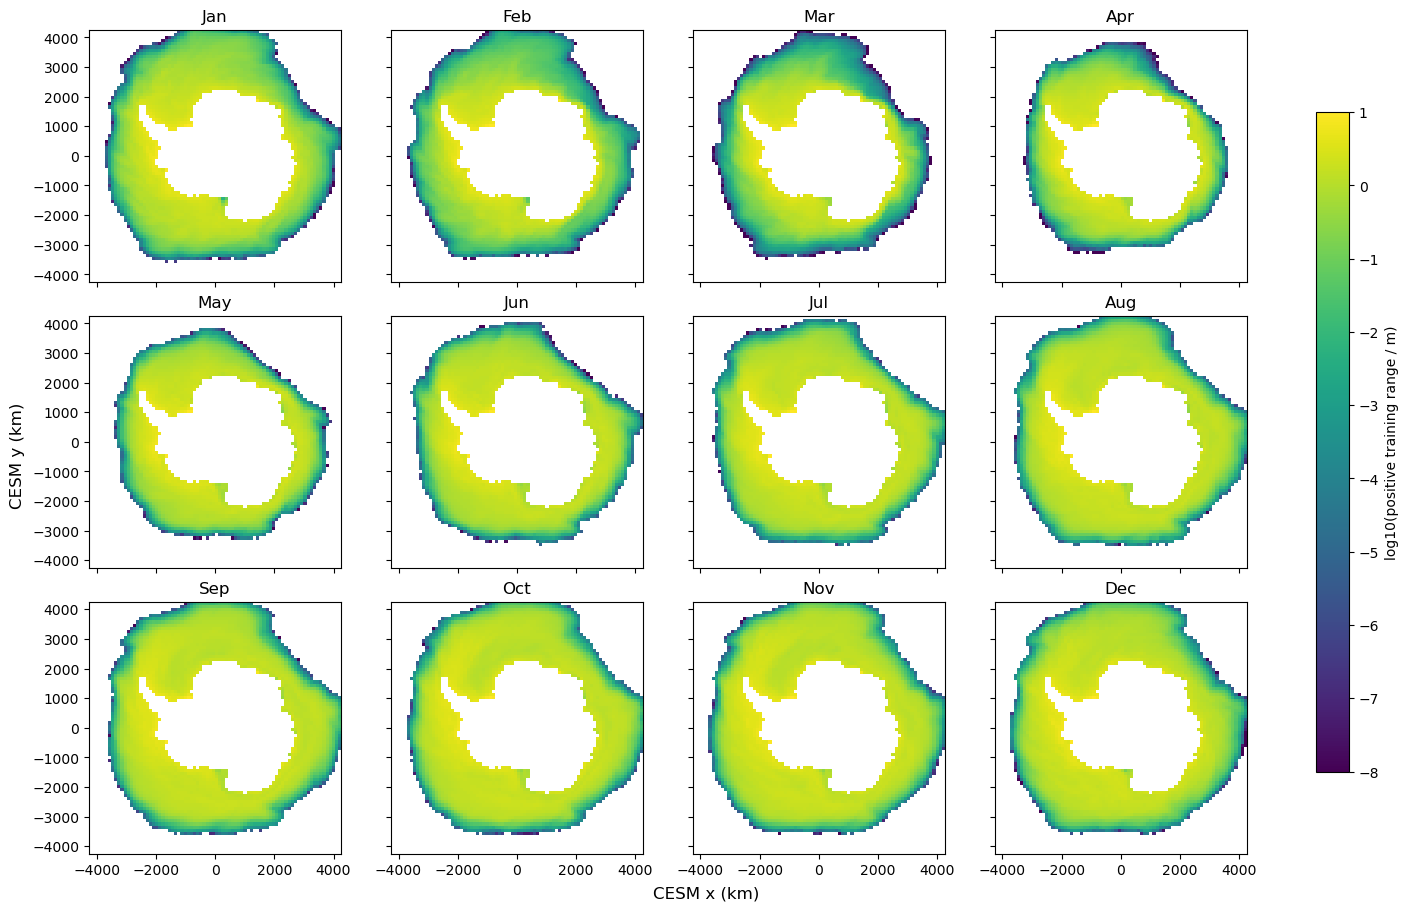

In [10]:
# Small training-statistic arrays are loaded once; raw data is streamed below.
range_thresholds_m = np.array([1e-12, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2])
floor_candidates_m = np.array([1e-6, 1e-4, 1e-3, 1e-2])
magnitude_cap = 10.0

with xr.open_dataset(min_path) as min_ds, xr.open_dataset(max_path) as max_ds, xr.open_dataset(norm_path) as norm_ds:
    triage_min = min_ds['icethick'].load()
    triage_max = max_ds['icethick'].load()
    triage_times = norm_ds.time.load()
triage_range = triage_max - triage_min
triage_month = pd.DatetimeIndex(triage_times.values).month.to_numpy()
range_values = triage_range.values
positive_range = range_values[range_values > 0]

overview = pd.Series({
    'finite cell-months': int(np.isfinite(range_values).sum()),
    'zero-range cell-months': int((range_values == 0).sum()),
    'smallest positive range (m)': float(positive_range.min()),
    '1st percentile positive range (m)': float(np.quantile(positive_range, .01)),
    'median positive range (m)': float(np.median(positive_range)),
})
display(overview.to_frame('value'))

month_rows = []
for month in range(1, 13):
    r = triage_range.sel(month=month).values
    positive = r[r > 0]
    row = {'month': month, 'positive cell-months': int(positive.size), 'zero range': int((r == 0).sum()),
           'median positive range (m)': float(np.median(positive))}
    row.update({f'range < {threshold:g} m': int(((r > 0) & (r < threshold)).sum())
                for threshold in range_thresholds_m})
    month_rows.append(row)
range_by_month = pd.DataFrame(month_rows).set_index('month')
display(range_by_month)

fig, axes = plt.subplots(3, 4, figsize=(14, 9), sharex=True, sharey=True, constrained_layout=True)
for month, ax in enumerate(axes.flat, start=1):
    r = triage_range.sel(month=month).values
    log_range = np.full_like(r, np.nan, dtype=float)
    positive = r > 0
    log_range[positive] = np.log10(r[positive])
    image = ax.pcolormesh(triage_range.x.values / 1000, triage_range.y.values / 1000,
                          log_range, shading='auto', vmin=-8, vmax=1)
    ax.set(title=pd.Timestamp(2001, month, 1).strftime('%b'), aspect='equal')
fig.colorbar(image, ax=axes, label='log10(positive training range / m)', shrink=.8)
fig.supxlabel('CESM x (km)'); fig.supylabel('CESM y (km)'); plt.show()


In [11]:
# Stream raw data by member. All normalized values in this cell are pre-detrending.
raw_path = Path(config_cesm.DATA_DIRECTORY) / 'cesm_data' / 'icethick' / 'icethick_combined.nc'
time_minimum = triage_min.sel(month=triage_month).values
time_range = triage_range.sel(month=triage_month).values
valid_denominator = time_range > 0
present_count = np.zeros_like(range_values, dtype=np.int64)
finite_count = np.zeros_like(range_values, dtype=np.int64)
split_summary, split_cell_max = {}, {}

with xr.open_dataset(raw_path) as raw_ds:
    for split in ('train', 'val', 'test'):
        total_finite, baseline_max, clipped_count = 0, 0.0, 0
        exceed = {threshold: 0 for threshold in (1, 2, 5, 8, 10, 100, 1e3, 1e6)}
        floor_changed = {floor: 0 for floor in floor_candidates_m}
        floor_max = {floor: 0.0 for floor in floor_candidates_m}
        cell_max = np.full_like(range_values, np.nan, dtype=float)
        for member_id in config.data_split[split]:
            raw = raw_ds['icethick'].sel(member_id=member_id, time=triage_times.values).values
            with np.errstate(divide='ignore', invalid='ignore'):
                z = (raw - time_minimum) / time_range
            finite, abs_z = np.isfinite(z), np.abs(z)
            if finite.any():
                total_finite += int(finite.sum()); baseline_max = max(baseline_max, float(np.nanmax(abs_z)))
                clipped_count += int((abs_z[finite] > magnitude_cap).sum())
                for threshold in exceed:
                    exceed[threshold] += int((abs_z[finite] > threshold).sum())
            for month in range(1, 13):
                ix = np.flatnonzero(triage_month == month)
                month_abs = np.where(np.isfinite(abs_z[ix]), abs_z[ix], -np.inf)
                month_max = np.max(month_abs, axis=0)
                month_max[month_max == -np.inf] = np.nan
                cell_max[month - 1] = np.fmax(cell_max[month - 1], month_max)
                if split == 'train':
                    raw_month = raw[ix]
                    finite_count[month - 1] += np.isfinite(raw_month).sum(axis=0)
                    present_count[month - 1] += (raw_month > .01).sum(axis=0)
            for floor in floor_candidates_m:
                floored_z = np.where(valid_denominator, (raw - time_minimum) / np.maximum(time_range, floor), np.nan)
                finite_floor = np.isfinite(floored_z)
                floor_changed[floor] += int((finite_floor & (time_range < floor)).sum())
                if finite_floor.any():
                    floor_max[floor] = max(floor_max[floor], float(np.nanmax(np.abs(floored_z))))
        split_cell_max[split] = cell_max
        split_summary[split] = {
            'finite values': total_finite, 'baseline max |z|': baseline_max,
            **{f'count |z| > {t:g}': exceed[t] for t in exceed},
            'fraction clipped at |z|=10': clipped_count / total_finite,
            **{f'fraction affected by {f:g} m floor': floor_changed[f] / total_finite for f in floor_candidates_m},
            **{f'max |z| with {f:g} m floor': floor_max[f] for f in floor_candidates_m},
        }
pre_detrend_summary = pd.DataFrame(split_summary).T
display(pre_detrend_summary)

present_fraction = np.divide(present_count, finite_count, out=np.full_like(range_values, np.nan, dtype=float), where=finite_count > 0)
location_table = (triage_range.to_dataframe(name='training_range_m').reset_index()
                  .assign(present_fraction=present_fraction.ravel(),
                          x_km=lambda x: x.x / 1000, y_km=lambda x: x.y / 1000)
                  .query('training_range_m > 0'))
display(location_table.sort_values('training_range_m')[['month', 'x_km', 'y_km', 'training_range_m', 'present_fraction']].head(25))


,finite values,baseline max |z|,count |z| > 1,count |z| > 2,count |z| > 5,count |z| > 8,count |z| > 10,count |z| > 100,count |z| > 1000,count |z| > 1e+06,fraction clipped at |z|=10,fraction affected by 1e-06 m floor,fraction affected by 0.0001 m floor,fraction affected by 0.001 m floor,fraction affected by 0.01 m floor,max |z| with 1e-06 m floor,max |z| with 0.0001 m floor,max |z| with 0.001 m floor,max |z| with 0.01 m floor
train,43539360.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.01708,0.064849,0.114183,0.187196,1.000000,1.000000,1.000000,1.000000
val,10884840.0,inf,6074.0,878.0,375.0,274.0,240.0,82.0,41.0,12.0,0.000022,0.01708,0.064849,0.114183,0.187196,3470.239861,110.748234,39.197937,11.229728
test,21769680.0,inf,16118.0,2515.0,1030.0,733.0,645.0,190.0,85.0,17.0,0.000030,0.01708,0.064849,0.114183,0.187196,53829.547018,538.295470,116.251253,25.571287


,month,x_km,y_km,training_range_m,present_fraction
4155,1,3781.804665,1225.091652,4.600255e-18,0.0
14060,3,2183.859032,-2609.977867,2.690791e-17,0.0
22872,4,3462.215538,585.913399,1.136113e-16,0.0
23210,4,-3142.626412,1118.561943,1.266833e-16,0.0
73199,12,4207.923500,-585.913399,1.421076e-16,0.0
14095,3,-2609.977867,-2503.448158,2.118264e-16,0.0
63293,10,-2823.037285,3355.685829,6.172040e-16,0.0
25089,4,1012.032234,3568.745247,8.109866e-16,0.0
12458,2,1970.799614,3781.804665,1.433642e-15,0.0
18775,3,1651.210488,3675.274956,1.692141e-15,0.0


,cell-months,median present fraction,val: cell-months with max |z| > 10,val: max |z|,test: cell-months with max |z| > 10,test: max |z|
range threshold (m),,,,,,
1.000000e-12,21,0.0,6,2.686344e+11,8,4.838241e+13
1.000000e-08,163,0.0,24,2.686344e+11,40,4.838241e+13
1.000000e-06,567,0.0,70,2.686344e+11,137,4.838241e+13
1.000000e-04,2153,0.0,172,2.686344e+11,362,4.838241e+13
1.000000e-03,3791,0.0,204,2.686344e+11,465,4.838241e+13
1.000000e-02,6215,0.0,222,2.686344e+11,513,4.838241e+13


,cell_months,median_present_fraction,val_median_max_abs_z,val_cell_months_over_10,test_median_max_abs_z,test_cell_months_over_10
range_bin,,,,,,
"(-18, -12]",21,0.000000,0.000000,6,0.000000,8
"(-12, -8]",142,0.000000,0.000000,18,0.000000,32
"(-8, -6]",404,0.000000,0.000000,46,0.000000,97
"(-6, -4]",1586,0.000000,0.000000,102,0.125287,225
"(-4, -3]",1638,0.000000,0.079895,32,0.340198,103
"(-3, -2]",2424,0.000000,0.216682,18,0.492459,48
"(-2, -1]",4012,0.003811,0.385615,0,0.637618,9
"(-1, 0]",8766,0.233232,0.719736,0,0.869598,0
"(0, 2]",14208,0.999238,0.882974,0,0.952495,0


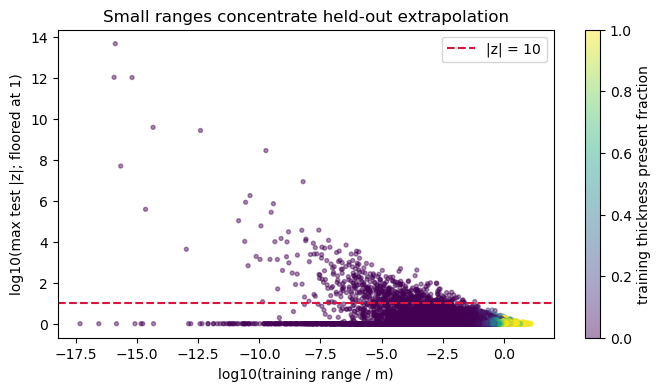

In [12]:
# Relate range to held-out extrapolation and marginal-ice context.
context_rows = []
for threshold in range_thresholds_m:
    mask = (range_values > 0) & (range_values < threshold)
    row = {'range threshold (m)': threshold, 'cell-months': int(mask.sum()),
           'median present fraction': float(np.nanmedian(present_fraction[mask]))}
    for split in ('val', 'test'):
        maximum = split_cell_max[split]
        row[f'{split}: cell-months with max |z| > 10'] = int((maximum[mask] > 10).sum())
        row[f'{split}: max |z|'] = float(np.nanmax(maximum[mask]))
    context_rows.append(row)
range_context = pd.DataFrame(context_rows).set_index('range threshold (m)')
display(range_context)

bins = np.array([-18, -12, -8, -6, -4, -3, -2, -1, 0, 2])
relationship = location_table.assign(range_bin=pd.cut(np.log10(location_table.training_range_m), bins=bins))
positive_mask = range_values.ravel() > 0
for split in ('val', 'test'):
    relationship[f'{split}_max_abs_z'] = split_cell_max[split].ravel()[positive_mask]
relationship_summary = relationship.groupby('range_bin', observed=True).agg(
    cell_months=('training_range_m', 'size'), median_present_fraction=('present_fraction', 'median'),
    val_median_max_abs_z=('val_max_abs_z', 'median'), val_cell_months_over_10=('val_max_abs_z', lambda x: (x > 10).sum()),
    test_median_max_abs_z=('test_max_abs_z', 'median'), test_cell_months_over_10=('test_max_abs_z', lambda x: (x > 10).sum()),
)
display(relationship_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(np.log10(location_table.training_range_m), np.log10(np.maximum(1, split_cell_max['test'].ravel()[positive_mask])),
                c=location_table.present_fraction, s=8, alpha=.45, cmap='viridis')
ax.axhline(np.log10(magnitude_cap), color='crimson', ls='--', label='|z| = 10')
ax.set(xlabel='log10(training range / m)', ylabel='log10(max test |z|; floored at 1)',
       title='Small ranges concentrate held-out extrapolation')
ax.legend(); fig.colorbar(sc, label='training thickness present fraction'); plt.show()


### Candidate policy evidence — no decision made

The preceding table compares counterfactual transforms of the existing raw data only:

- **Magnitude clip:** retain the current positive-range denominator and clip pre-detrending normalized values to $[-10,10]$. Values inside that interval are unchanged.
- **Denominator floor:** replace a positive range $r$ by $\max(r,f)$ for candidate floors $f=10^{-6},10^{-4},10^{-3},10^{-2}$ m. This attenuates all values at affected cell-months, including training values, and does not define a treatment for exact-zero ranges.

Exact-zero ranges, land/never-finite cells, a physical mask threshold, one-sided versus symmetric clipping, and the final floor/cap are scientific-policy choices requiring approval. Any selected policy must be implemented and validated only after the corrected training-only detrending preprocessing is used; old normalized artifacts remain unsuitable for reruns.
